In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load the anomaly dataset we used yesterday
url = "https://raw.githubusercontent.com/waico/SKAB/master/data/valve1/1.csv"
df = pd.read_csv(url, sep=';', index_col='datetime', parse_dates=True)

# Separate features (sensor readings) from labels (answers)
feature_columns = ['Accelerometer1RMS', 'Accelerometer2RMS', 
                   'Current', 'Pressure', 'Temperature', 
                   'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

X = df[feature_columns]  # This is what the model sees
y_true = df['anomaly']   # This is the answer key - model never sees this

print("Features shape:", X.shape)
print("Features (what model sees):")
print(X.head(3))
print("\nAnswer key (what model never sees):")
print(y_true.head(3))
print("\nModel's job: look at X only and figure out which rows are anomalies")

Features shape: (1145, 8)
Features (what model sees):
                     Accelerometer1RMS  Accelerometer2RMS   Current  Pressure  \
datetime                                                                        
2020-03-09 10:34:33           0.027080           0.039615  0.871339  0.054711   
2020-03-09 10:34:34           0.026995           0.038759  1.301280  0.054711   
2020-03-09 10:34:35           0.026807           0.039521  1.284500  0.382638   

                     Temperature  Thermocouple  Voltage  Volume Flow RateRMS  
datetime                                                                      
2020-03-09 10:34:33      75.4955       25.8338  244.091              32.0000  
2020-03-09 10:34:34      75.5445       25.8408  224.170              32.0000  
2020-03-09 10:34:35      75.6607       25.8227  234.157              32.9986  

Answer key (what model never sees):
datetime
2020-03-09 10:34:33    0.0
2020-03-09 10:34:34    0.0
2020-03-09 10:34:35    0.0
Name: anomaly, dty

In [2]:
# Train Isolation Forest
model = IsolationForest(
    contamination=0.35,  # We know 35% of data is anomalous
    random_state=42      # Makes results reproducible
)

# Train the model - it only sees X, never y_true
model.fit(X)

# Make predictions
predictions = model.predict(X)

print("Raw predictions (first 10):", predictions[:10])
print("\nUnique values in predictions:", set(predictions))

Raw predictions (first 10): [ 1  1 -1 -1 -1  1 -1  1 -1 -1]

Unique values in predictions: {np.int64(1), np.int64(-1)}


In [3]:
# Convert Isolation Forest output to match our answer key
# Isolation Forest: 1=normal, -1=anomaly
# Our answer key: 0=normal, 1=anomaly
# We need to convert so we can compare them

y_pred = (predictions == -1).astype(int)

print("Converted predictions (first 10):", y_pred[:10])
print("Answer key (first 10):          ", y_true.values[:10])
print("\nPredicted anomalies:", y_pred.sum())
print("Actual anomalies:", int(y_true.sum()))

Converted predictions (first 10): [0 0 1 1 1 0 1 0 1 1]
Answer key (first 10):           [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Predicted anomalies: 401
Actual anomalies: 402


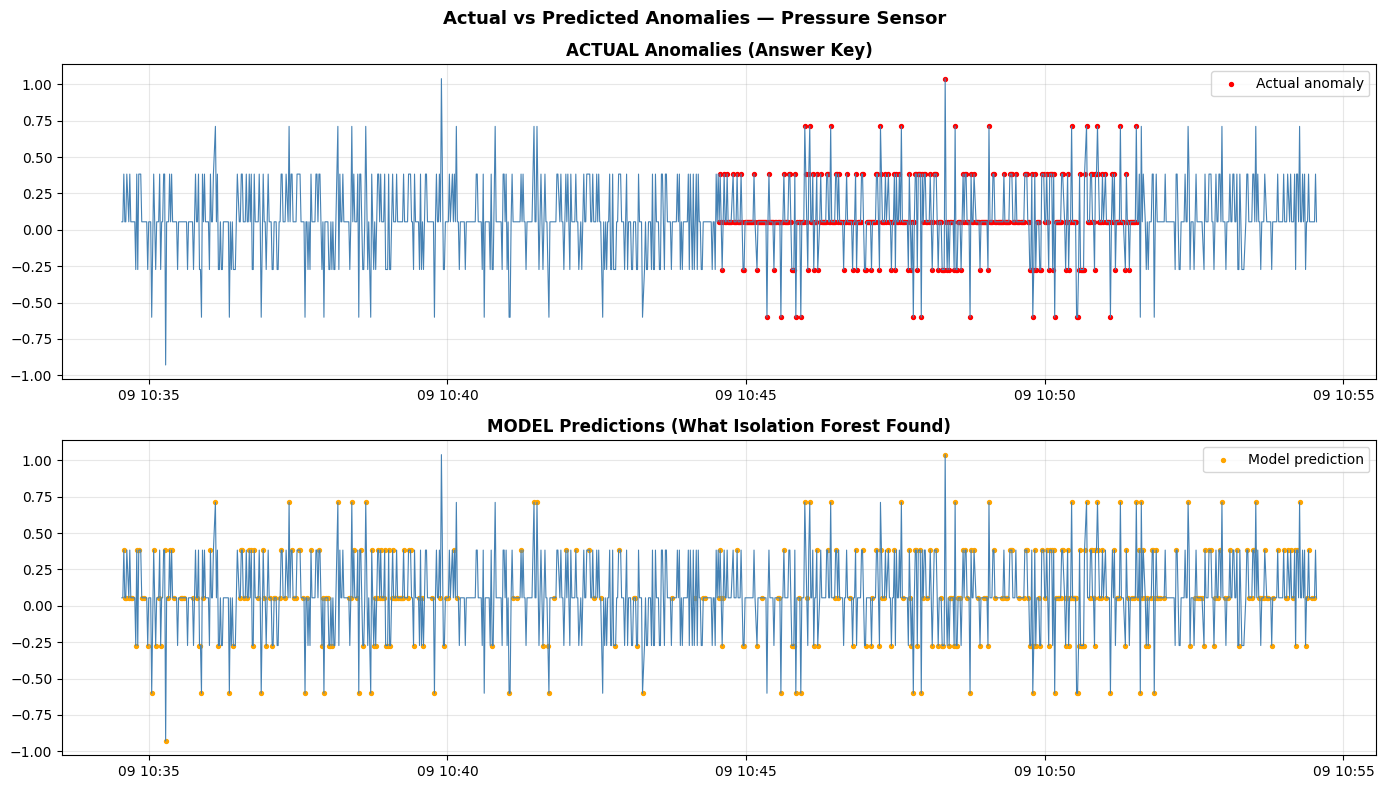

Top chart = where anomalies actually happened
Bottom chart = where the model THINKS anomalies happened
Good model = both charts look similar


In [4]:
# Add predictions back to the dataframe for visualisation
df['predicted_anomaly'] = y_pred

# Plot Pressure with actual vs predicted anomalies
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top chart: actual anomalies (ground truth)
axes[0].plot(df.index, df['Pressure'], color='steelblue', linewidth=0.8)
actual_mask = df['anomaly'] == 1.0
axes[0].scatter(df.index[actual_mask], df['Pressure'][actual_mask],
                color='red', s=8, label='Actual anomaly')
axes[0].set_title('ACTUAL Anomalies (Answer Key)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom chart: model predictions
axes[1].plot(df.index, df['Pressure'], color='steelblue', linewidth=0.8)
pred_mask = df['predicted_anomaly'] == 1
axes[1].scatter(df.index[pred_mask], df['Pressure'][pred_mask],
                color='orange', s=8, label='Model prediction')
axes[1].set_title('MODEL Predictions (What Isolation Forest Found)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Anomalies — Pressure Sensor', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/actual_vs_predicted.png', dpi=100, bbox_inches='tight')
plt.show()

print("Top chart = where anomalies actually happened")
print("Bottom chart = where the model THINKS anomalies happened")
print("Good model = both charts look similar")

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

print("MODEL PERFORMANCE REPORT")
print("="*40)
print(classification_report(y_true, y_pred, 
                            target_names=['Normal', 'Anomaly']))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
print(f"True Negatives  (correctly said normal):    {cm[0][0]}")
print(f"False Positives (wrongly said anomaly):     {cm[0][1]}")
print(f"False Negatives (missed real anomaly):      {cm[1][0]}")
print(f"True Positives  (correctly caught anomaly): {cm[1][1]}")

MODEL PERFORMANCE REPORT
              precision    recall  f1-score   support

      Normal       0.69      0.69      0.69       743
     Anomaly       0.43      0.43      0.43       402

    accuracy                           0.60      1145
   macro avg       0.56      0.56      0.56      1145
weighted avg       0.60      0.60      0.60      1145


Confusion Matrix:
True Negatives  (correctly said normal):    515
False Positives (wrongly said anomaly):     228
False Negatives (missed real anomaly):      229
True Positives  (correctly caught anomaly): 173
